# Análisis Exploratorio de Ventas - Superstore

El dataset Superstore recoge las transacciones de ventas de una gran superficie estadounidense entre 2015 y 2018. Cada fila representa un pedido de producto con información sobre la ubicación, el cliente y los resultados económicos de la venta. 

## Objetivo
Identificar qué categorías, productos y prácticas comerciales generan beneficios y cuáles generan pérdidas, así como cualquier otro insight de valor, con el fin de proponer recomendaciones accionables para el negocio. 

## Stack utilizado
- **Pandas**: Carga de los datos, limpieza y análisis. 
- **Matplotlib y Seaborn**: Visualización 
- **Streamlit**: Dashboard interactivo ([ver app desplegada](https://proyecto-eda-ventas-nsdlcb5tjamt8j46uxpun7.streamlit.app/))

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 100
BASE_DIR = Path().resolve().parent
df = pd.read_csv(BASE_DIR / 'data' / 'superstore.csv', encoding='latin-1')


## 1. Exploración inicial del dataset
Lo primero es hacer un análisis de la estructura de los datos para entenderlos completamente: qué representan, que columnas hay, si existen valores nulos y el rango de las variables numéricas. 

In [26]:
display(df.head())
display(df.dtypes)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

In [27]:
display(df.describe())
df.isnull().sum()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

### Observaciones
- Cada fila representa una linea de pedido (un producto concreto dentro de un pedido)
- Un mismo pedido puede tener varias filas con distinta categoría o producto
- No hay valores nulos en ninguna columna por lo que no hay que hacer ningún tipo de imputación
- La variable de beneficios 'Profit' tiene una media de 28,66 pero una desviación estándar de 234,26, indicando alta variabilidad (algunas transacciones son muy rentables y otras generan grandes pérdidas)
- Los descuentos llegan hasta el 80%, lo que podría tener relación con las pérdidas. 

## 2. Preparación de datos
Antes de analizar, convertimos las columnas de fecha y extraemos el año y mes 
para poder hacer análisis temporal más adelante.


In [28]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month

print(f"Rango temporal: {df['Year'].min()} — {df['Year'].max()}")
print(f"Años: {sorted(df['Year'].unique())}")

Rango temporal: 2014 — 2017
Años: [np.int32(2014), np.int32(2015), np.int32(2016), np.int32(2017)]


## 3. Preguntas de negocio
1. ¿Qué categorías y productos son los más rentables?
2. ¿Qué regiones generan más beneficio?
3. ¿Los descuentos altos siempre generan pérdidas?
4. ¿Hay productos que no merezca la pena mantener en el catálogo?
5. ¿Cómo ha evolucionado la rentabilidad a lo largo del tiempo?

## 4. Rentabilidad por categoría y producto
Analizamos qué categorías y subcategorías reportan mayores beneficios para el negocio, identificando tanto las más rentables como las que generan pérdidas

In [29]:
cat_mas_rentables = df.groupby('Category')['Profit'].sum().sort_values(ascending=False)
subcat_mas_rentables = df.groupby('Sub-Category')['Profit'].sum().sort_values(ascending=False)

print(cat_mas_rentables.to_frame())
print(subcat_mas_rentables.to_frame())

                      Profit
Category                    
Technology       145454.9481
Office Supplies  122490.8008
Furniture         18451.2728
                  Profit
Sub-Category            
Copiers       55617.8249
Phones        44515.7306
Accessories   41936.6357
Paper         34053.5693
Binders       30221.7633
Chairs        26590.1663
Storage       21278.8264
Appliances    18138.0054
Furnishings   13059.1436
Envelopes      6964.1767
Art            6527.7870
Labels         5546.2540
Machines       3384.7569
Fasteners       949.5182
Supplies      -1189.0995
Bookcases     -3472.5560
Tables       -17725.4811


Top 3 subcategorias más rentables:
Sub-Category
Copiers        55617.8249
Phones         44515.7306
Accessories    41936.6357
Name: Profit, dtype: float64

Top 3 subcategorias menos rentables:
Sub-Category
Supplies     -1189.0995
Bookcases    -3472.5560
Tables      -17725.4811
Name: Profit, dtype: float64


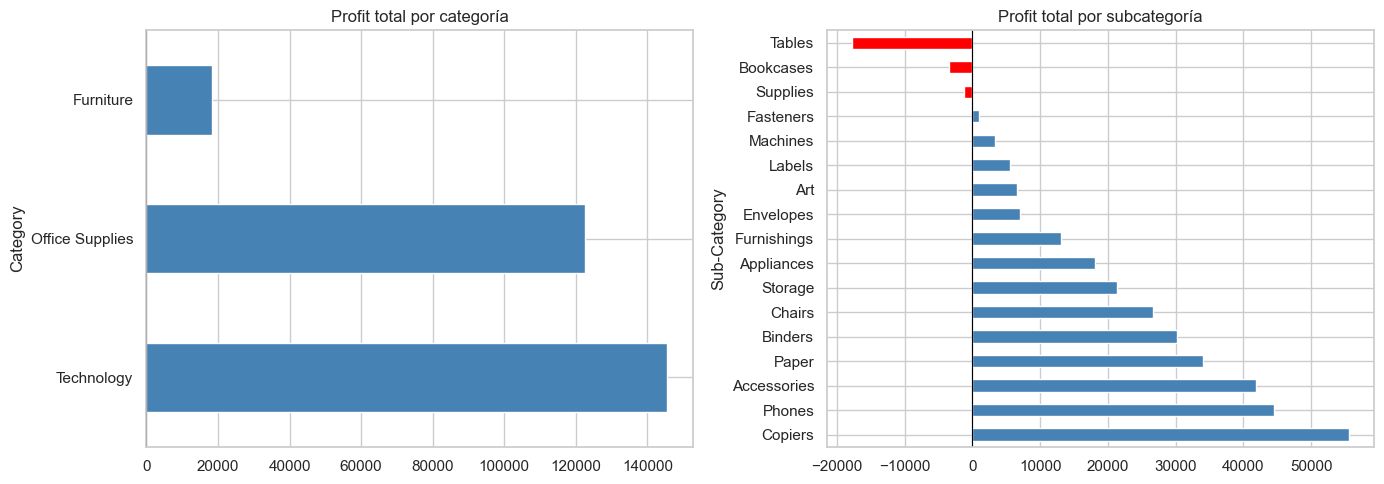

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cat_colors = ['red' if x < 0 else 'steelblue' for x in cat_mas_rentables]
cat_mas_rentables.plot(kind='barh', ax=axes[0], color=cat_colors)
axes[0].axvline(x=0, color='black', linewidth=0.8)
axes[0].set_title('Profit total por categoría')

subcat_colors = ['red' if x < 0 else 'steelblue' for x in subcat_mas_rentables]
subcat_mas_rentables.plot(kind='barh', ax=axes[1], color=subcat_colors)
print("Top 3 subcategorias más rentables:")
print(subcat_mas_rentables.head(3))
print("\nTop 3 subcategorias menos rentables:")
print(subcat_mas_rentables.tail(3))
subcat_mas_rentables = subcat_mas_rentables.sort_values(ascending=False)
axes[1].axvline(x=0, color='black', linewidth=0.8)
axes[1].set_title('Profit total por subcategoría')

plt.tight_layout()
plt.show()

### Observaciones
- **Technology** es la categoría de producto que genera mayor rentabilidad con diferencia, liderada por Copiers y Phones. 
- **Furniture** es la categoría con menor rentabilidad, muy lastrada por las pérdidas en Tables (-17.725$) y Bookcases (-3.473$).
- Tres subcategorías están en pérdidas (Tables, Bookcases y Supplies). Su eliminación del catálogo merece ser estudiada en especial Tables y Bookcases
- Las sillas (Chairs) no son suficientemente rentables como para compensar las pérdiads del resto de la categoría de mobiliario por lo que se podría estudiar incluso la eliminación completa de dicha vertical. 


## 5. Relación entre descuentos y rentabilidad
Uno de los hallazgos más relevantes del análisis es la relación entre el nivel de descuento aplicado y el profit generado. Analizamos a partir de qué umbral los descuentos dejan de ser rentables.

In [31]:

descuento_profit = df.groupby('Discount')['Profit'].mean().sort_values(ascending=False)
display(descuento_profit.to_frame().style.format({'Profit': '{:.2f}'}))

,Profit
Discount,
0.100000,96.06
0.000000,66.90
0.150000,27.29
0.200000,24.70
0.600000,-43.08
0.300000,-45.68
0.320000,-88.56
0.700000,-95.87
0.800000,-101.80


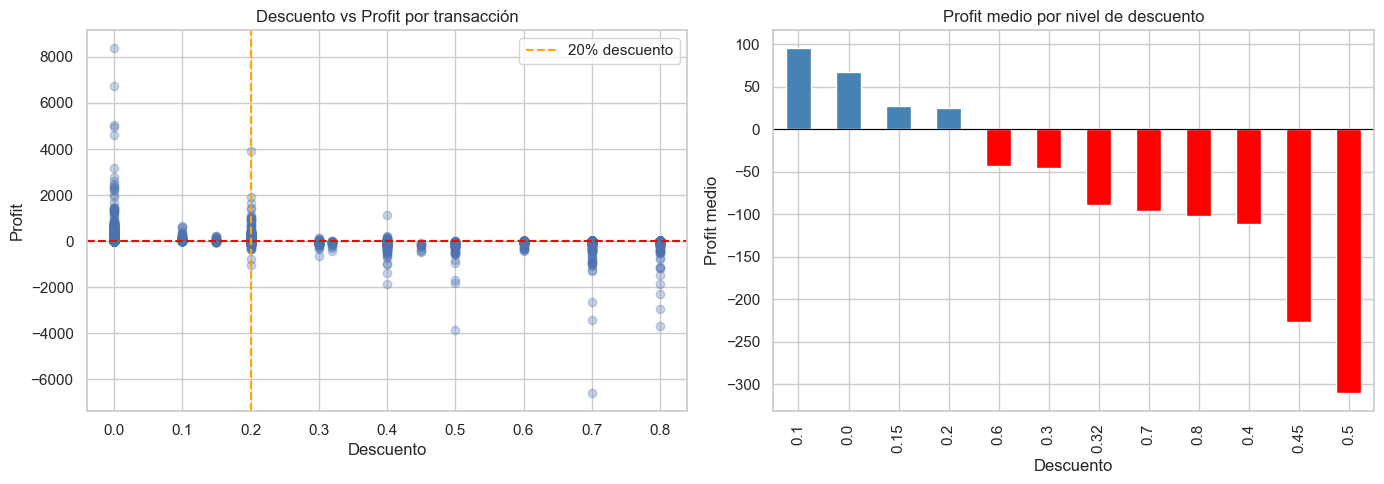

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df['Discount'], df['Profit'], alpha=0.3)
axes[0].axhline(y=0, color='red', linestyle='--')
axes[0].axvline(x=0.2, color='orange', linestyle='--', label='20% descuento')
axes[0].set_xlabel('Descuento')
axes[0].set_ylabel('Profit')
axes[0].set_title('Descuento vs Profit por transacción')
axes[0].legend()


desc_colors = ['red' if x < 0 else 'steelblue' for x in descuento_profit]
descuento_profit.plot(kind='bar', ax=axes[1], color=desc_colors)
axes[1].axhline(y=0, color='black', linewidth=0.8)
axes[1].set_title('Profit medio por nivel de descuento')
axes[1].set_xlabel('Descuento')
axes[1].set_ylabel('Profit medio')

plt.tight_layout()
plt.show()

### Observaciones
- Los descuentos del 0% y 10% son los más rentables de media.
- A partir del 20-30% la media de profit se vuelve negativa.
- A partir del 40% prácticamente no existe ninguna transacción rentable.
- Los descuentos del 45% y 50% tienen la peor media, probablemente por tener mayor valúmen de transacciones a las que se aplican estos descuentos (hay muchas más transacciones con estos descuentos que con el 70-80%)
- Los descuentos más altos (70-80%), aunque generan pérdidas individuales mayores, tienen una media menos negativa por el menor volumen de transacciones. Podrían responder a correcciones de stock o necesidad deliquidaciones puntuales. 

- **Recomendación:** estudiar la eliminación general de descuentos superiores al 40% ya que no generan rentabilidad en ningún caso.

## 6. Rentabilidad por región
Analizamos qué regiones geográficas generan más beneficio, tanto en términos de profit total como de eficiencia por transacción.

In [33]:
region_profit = df.groupby('Region').agg(
    Profit_Total=('Profit', 'sum'),
    Profit_Medio=('Profit', 'mean'),
    Num_Transacciones=('Profit', 'count')
).sort_values('Profit_Total', ascending=False)

display(region_profit.style.format('{:.2f}'))

,Profit_Total,Profit_Medio,Num_Transacciones
Region,,,
West,108418.45,33.85,3203.00
East,91522.78,32.14,2848.00
South,46749.43,28.86,1620.00
Central,39706.36,17.09,2323.00


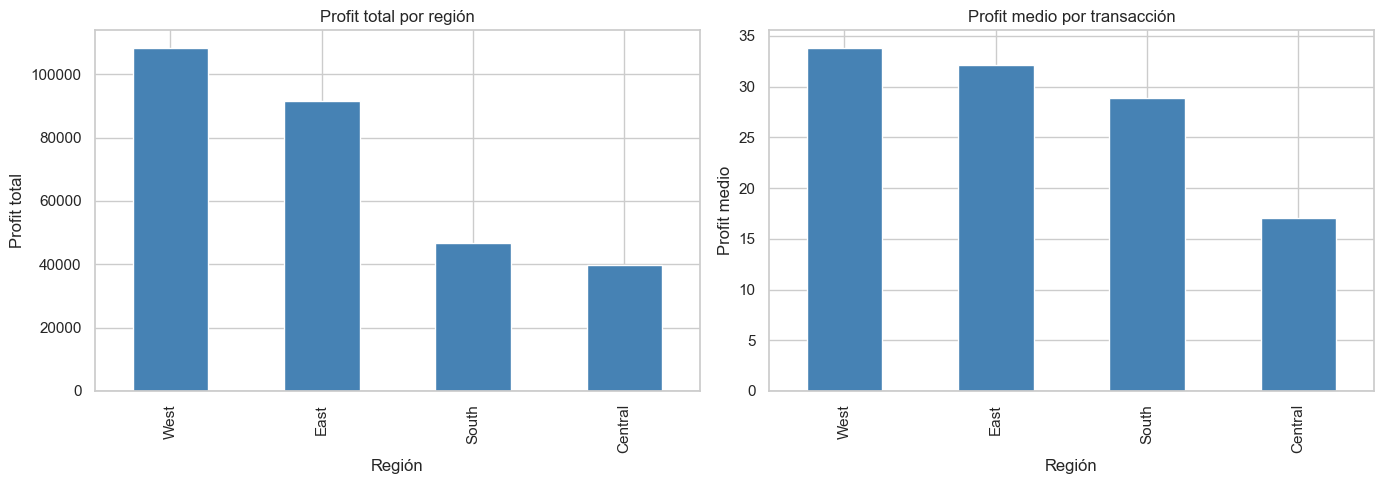

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

region_profit['Profit_Total'].plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].axhline(y=0, color='black', linewidth=0.8)
axes[0].set_title('Profit total por región')
axes[0].set_xlabel('Región')
axes[0].set_ylabel('Profit total')

region_profit['Profit_Medio'].plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].axhline(y=0, color='black', linewidth=0.8)
axes[1].set_title('Profit medio por transacción')
axes[1].set_xlabel('Región')
axes[1].set_ylabel('Profit medio')

plt.tight_layout()
plt.show()

### Observaciones
- Todas las regiones son rentables y no hay ninguna con profit negativo.
- West es la región más rentable tanto en total como en eficiencia por transacción.
- Central es la región con peor rendimiento
- La diferencia entre total y media por transacción es pequeña entre regiones, lo que sugiere que West no solo vende más volumen sino que también es más eficiente.
  
- **Recomendación:** estudiar qué prácticas de West se pueden replicar en Central para mejorar su rentabilidad y eficiencia. 

## 7. Evolución temporal de la rentabilidad
Analizamos cómo ha evolucionado el profit a lo largo de los 4 años del dataset, tanto a nivel global como por categoría y subcategoría. 

El objetivo es detectar tendencias de crecimiento, estacionalidad o cambios bruscos que requieran atención.

In [35]:

profit_anual = df.groupby('Year')['Profit'].sum()
display(profit_anual.to_frame())

,Profit
Year,
2014,49543.9741
2015,61618.6037
2016,81795.1743
2017,93439.2696


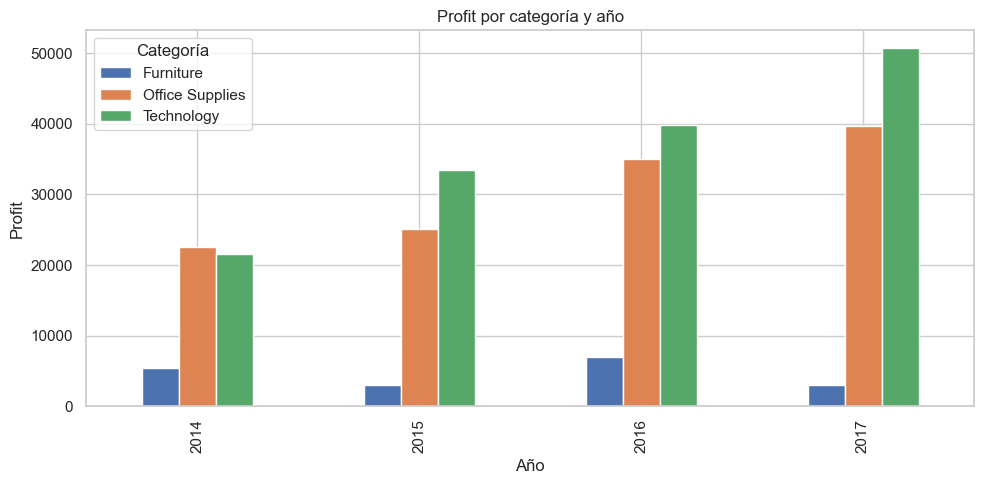

In [36]:

profit_year_cat = df.groupby(['Year', 'Category'])['Profit'].sum().unstack()

profit_year_cat.plot(kind='bar', figsize=(10, 5))
plt.title('Profit por categoría y año')
plt.xlabel('Año')
plt.ylabel('Profit')
plt.legend(title='Categoría')
plt.tight_layout()
plt.show()

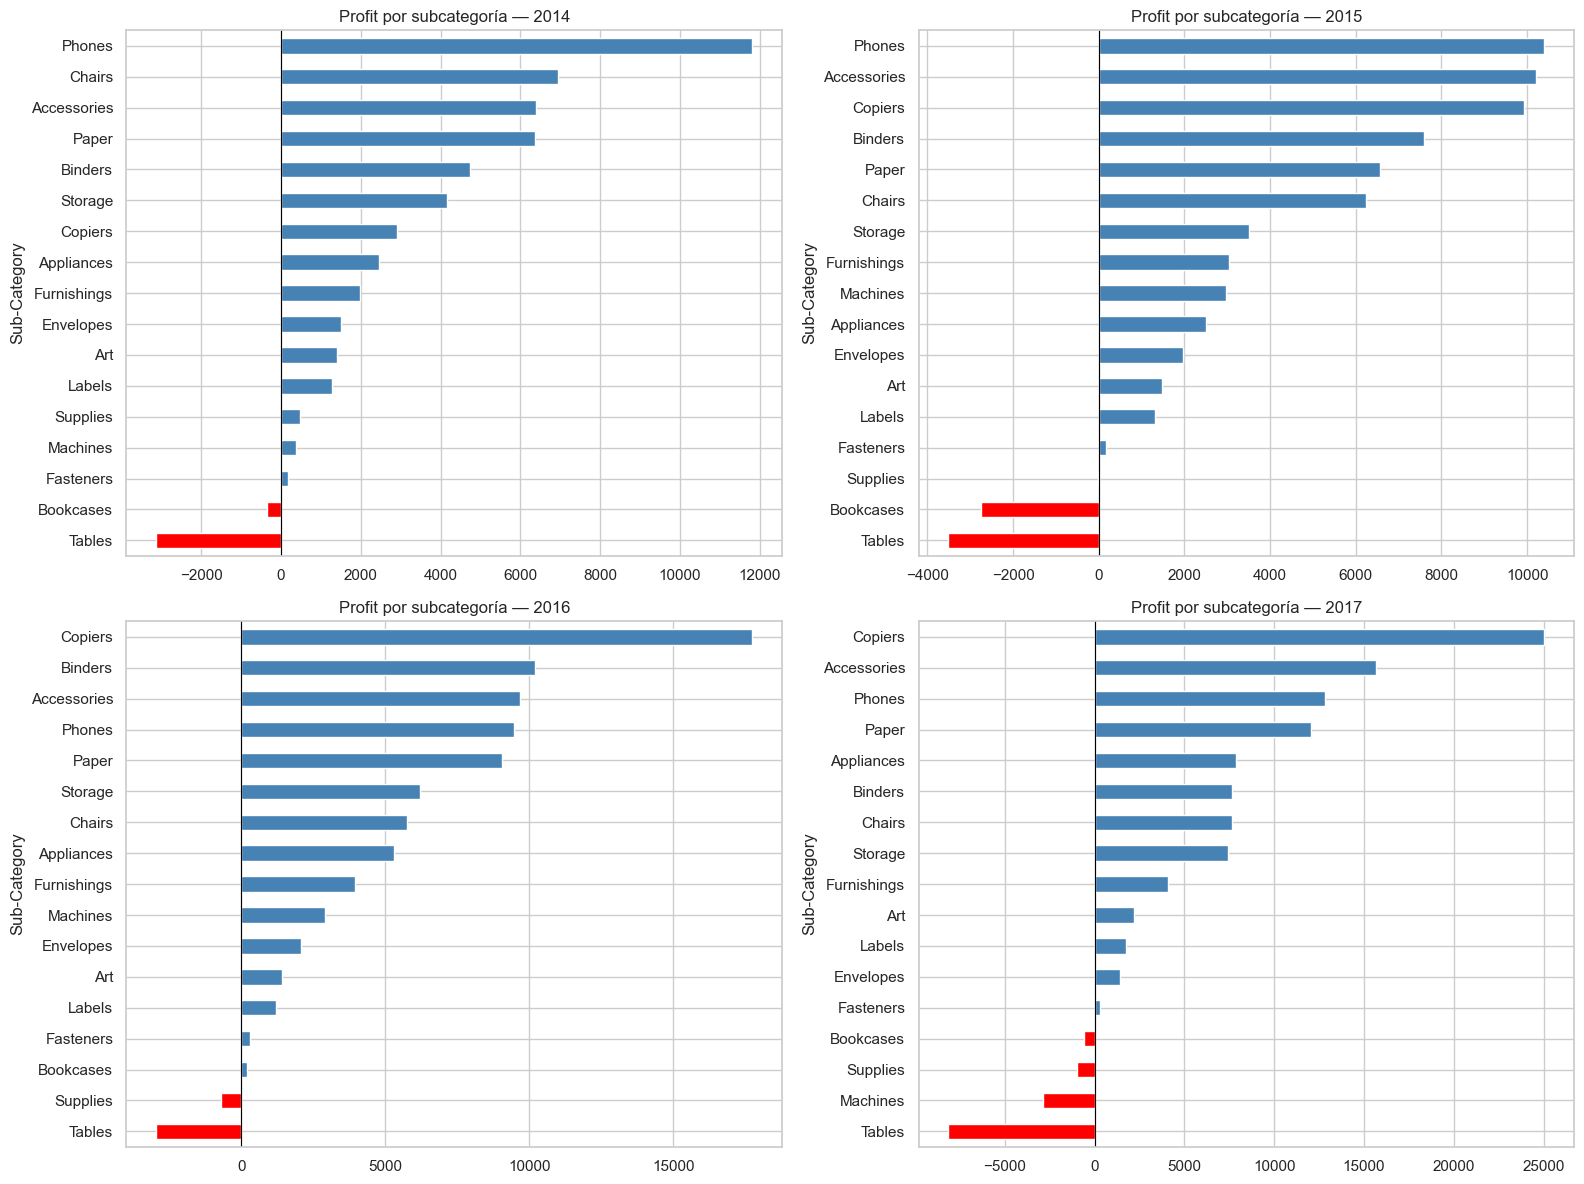

In [37]:
años = sorted(df['Year'].unique())
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, year in enumerate(años):
    data = df[df['Year'] == year].groupby('Sub-Category')['Profit'].sum().sort_values()
    colors = ['red' if x < 0 else 'steelblue' for x in data]
    data.plot(kind='barh', ax=axes[i], color=colors)
    axes[i].axvline(x=0, color='black', linewidth=0.8)
    axes[i].set_title(f'Profit por subcategoría — {year}')

plt.tight_layout()
plt.show()

### Observaciones
- El negocio muestra una tendencia de crecimiento consistente, aumentando año tras año. 
- El patrón de categorías se mantiene estable año tras año, con Technology liderando y Furniture siendo el más debil
- Tables genera pérdidas sistemáticas en los 4 años, convirtiendose en un problema estructural. 
- Bookcases oscila entre pérdidas y beneficios nulos, sin aportar valor. 
- El hallazgo más relevante es, sin duda, un cambio en la tendencia en Machines. Pasó de ser rentble en 2014-2016 a generar pérdidas significativas en 2017. 
Convendría investigación inmediata en un contexto real.  

## 8. Conclusiones e insights clave

A continuación se resumen los hallazgos más relevantes del análisis, ordenados por importancia para el negocio.

### Alertas (acción inmediata)
**1. Tables destruyen valor de forma sistemática**
Acumula -17.725$ de beneficio a lo largo de 4 años consecutivos de pérdidas, demostrando que no es un problema puntual. Se recomienda estudiar su eliminación del catálogo o una revisión profunda de su precio y políticas de descuento aplicadas. 

**2. Machines muestra un cambio de tendencia importante**
Tras ser rentables durante los primeros 3 años, entran en pérdidas en 2017 por lo que habría que iniciar una investigación inmediata para identificar el motivo real. Podría deberse a la aparición de nuevos competidores, cambios de proveedor, una política de descuentos más agresiva...

**3. Los descuentos superiores al 40% nunca son rentables**
Sin excepción, ninguna transacción con descuento mayor al 40% genera profit positivo. La política de descuentos actual está destruyendo margen sin justificación clara.


### Oportunidades (áreas a potenciar)
**4. Technology es el motor de negocio**
Copiers, Phones y Accessories lideran el profit de forma consistente. Potenciar esta vertical y ampliar su catálogo podría tener un impacto directo en resultados.

**5. Furniture podría ser un lastre**
En contraposición, la categoría de mueblería no da un profit ta relevante y sus pérdidas son las que más lastran el negocio. La eliminación de esta vertical, podría resultar beneficiosa recortando pérdidas innecesarias. 

**6. West supera a Central en un ratio de 2.73x**
Siendo todas las regiones rentables, la brecha entre West y Central sugiere que hay prácticas comerciales en West que podrían replicarse en otras regiones. Convendría el análisis de las diferencias operativas y de captación entre laas dos áreas. 


*Análisis realizado sobre el dataset Sample Superstore (Kaggle) — 9.994 transacciones, 2015-2018.*
*https://www.kaggle.com/datasets/vivek468/superstore-dataset-final*